# Lecture 4 — Practical: *Comparing Model Families, and the Validation That Keeps Them Honest*
### Practical Machine Learning for Transcriptomics in Cancer Research

A fair, honest **model bake-off**. You take the engineered features from Lecture 3 and:

1. compare **Logistic Regression / Random Forest / Gradient Boosting** on the *same* features & metrics,
2. **tune** one model (grid/random search) and measure how much tuning inflates a naive estimate,
3. estimate honestly with **nested cross-validation** — and measure the *optimism gap*,
4. run a **batch-correction experiment** (METABRIC → a *simulated* external cohort, with vs without, done correctly *and* the wrong way),
5. interpret **feature importances** with stability checks (prediction ≠ causation),
6. **choose a model for publication** justified on robustness, interpretability, reproducibility, and
   validated performance — *not* raw AUC.

> **The thesis you are testing:** *better validation is usually more important than a better algorithm.*
> Expect the honest result to be **deflationary** — the tuned complex models likely do not convincingly
> beat the baseline once nested CV and external validation are applied. **That deflation is the lesson.**

#### Continuity & reminders
- **Label:** binary **recurrence** — *not* pCR. The binary label is a deliberate simplification of
  time-to-event data (paid back in Lecture 5).
- **Only the model changes** across the bake-off (mirrors Lecture 3, where only the representation changed).
- **Leakage discipline (extended to batch correction):** scaling, selection, *and batch correction* are
  fit on training data only and applied to held-out/external data — never pooled across the split.
- **Same data cache as Lectures 1–3** — METABRIC is reused, not re-downloaded. (This practical needs only METABRIC; the external cohort is simulated in-notebook.)

> **Network note.** Reuses the L1–L3 real-data loaders (cBioPortal + GEO). If the prepared cohort is in
> the shared cache it is used directly; otherwise regenerated (needs internet). Downloads are git-ignored.


## Setup

Environment and data are prepared by **Lesson 0** (conda env `ml26` + downloads). This cell only
imports libraries and the checkpoint helpers — it installs nothing.

### 📚 Official docs & resources for this lesson

New to a tool, or want the authoritative reference? These point at exactly what this notebook uses. (Lesson 0 has the full library table.)

- **Core stack** — [NumPy](https://numpy.org/doc/stable/) · [pandas](https://pandas.pydata.org/docs/) · [Matplotlib](https://matplotlib.org/stable/index.html)
- **scikit-learn** — [Ensembles — Random Forest, Gradient Boosting](https://scikit-learn.org/stable/modules/ensemble.html) · [Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) · [Tuning hyper-parameters — grid / random search](https://scikit-learn.org/stable/modules/grid_search.html) · [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) · [Metrics & scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **Going deeper** — [Nested cross-validation — worked example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html) · [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)


In [2]:
# ── Setup — imports + checkpoint I/O (environment & data come from LESSON 0) ────
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (StratifiedKFold, cross_val_score, cross_val_predict,
                                     train_test_split, GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score

# ── checkpoint I/O — the data hand-off between lessons ─────────────────────────
# Each lesson SAVES what the next one needs and LOADS what the previous one made.
# Checkpoints live in the shared datasets/derived/ folder (git-ignored).
import pickle

def _derived_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for d in sorted((base / "lessons").glob("lesson01_*/practical/task/datasets")):
            (d / "derived").mkdir(parents=True, exist_ok=True)
            return d / "derived"
    d = Path.cwd() / "datasets" / "derived"; d.mkdir(parents=True, exist_ok=True)
    return d

def save_checkpoint(name, **objs):
    path = _derived_dir() / f"{name}.pkl"
    with open(path, "wb") as fh:
        pickle.dump(objs, fh)
    print(f"saved checkpoint '{name}'  ->  {path}")
    return path

def load_checkpoint(name):
    path = _derived_dir() / f"{name}.pkl"
    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint '{name}' not found ({path}).\n"
            f"Run the earlier lesson that creates it first — it ends with "
            f"save_checkpoint('{name}', ...).")
    with open(path, "rb") as fh:
        return pickle.load(fh)


### Load the engineered features from Lesson 3

> **Reminder — this notebook builds on Lesson 3.** It **loads** the `lesson03_features` checkpoint
> (engineered signature/pathway features + the Lesson-1 split); it does not rebuild them. If the load
> fails, run **Lesson 3** first (and Lesson 1 before it).

In [3]:
# Fixed, pre-published gene lists (from Lesson 3) -> leakage-exempt features / batch-robust reps.
SIGNATURES = {
    "proliferation": ["MKI67","AURKA","CCNB1","CCNB2","BUB1","TOP2A","CDK1","CCNE2","MYBL2","UBE2C","BIRC5","RRM2","TYMS","CENPF","PLK1"],
    "er_signalling": ["ESR1","FOXA1","GATA3","XBP1","BCL2","PGR","TFF1","GREB1","AR","NAT1","MLPH"],
    "immune":        ["CD8A","CD8B","GZMB","PRF1","IFNG","CXCL9","CXCL10","CD3D","CD3E","GZMA","NKG7","STAT1"],
    "stromal":       ["FAP","COL1A1","COL1A2","COL3A1","ACTA2","PDGFRB","FN1","VIM","THY1","SPARC","TIMP1"],
}
HALLMARK_SETS = {
    "E2F_TARGETS":      ["MKI67","BUB1","CCNB2","AURKA","TOP2A","RRM2","MYBL2","CDK1"],
    "G2M_CHECKPOINT":   ["CCNB1","CCNB2","PLK1","BUB1","CENPF","UBE2C","BIRC5","CDK1"],
    "ESTROGEN_EARLY":   ["ESR1","FOXA1","GATA3","TFF1","GREB1","PGR","XBP1"],
    "ESTROGEN_LATE":    ["BCL2","NAT1","MLPH","AR","ESR1","TFF1"],
    "INTERFERON_GAMMA": ["CXCL9","CXCL10","STAT1","IFNG","GZMB","PRF1"],
    "INFLAMMATORY":     ["CD8A","CD3D","CD3E","GZMA","NKG7","CD8B"],
    "EMT":              ["COL1A1","COL1A2","COL3A1","FN1","VIM","SPARC","ACTA2"],
    "ANGIOGENESIS":     ["PDGFRB","TIMP1","FAP","THY1","SPARC"],
    "APOPTOSIS":        ["BCL2","BIRC5","TIMP1","GZMB"],
    "MYC_TARGETS":      ["RRM2","TYMS","CCNE2","UBE2C","CDK1","MYBL2"],
}
def score_sets(X, sets):
    """Mean of standardised member genes -> one score per set (leakage-exempt: fixed lists)."""
    cols = {}
    for name, genes in sets.items():
        present = [g for g in genes if g in X.columns]
        if not present:
            continue
        z = (X[present] - X[present].mean()) / (X[present].std() + 1e-9)
        cols[name] = z.mean(axis=1)
    return pd.DataFrame(cols, index=X.index)

# Load the engineered features that LESSON 3 saved. Strict hand-off: if this raises, run
# Lesson 3 first (its final cell writes the 'lesson03_features' checkpoint).
d = load_checkpoint("lesson03_features")
X_genes, X_feat, clin_all, y_all = d["X_genes"], d["feats"], d["clin"], d["y"]
tr, va, te = d["tr"], d["va"], d["te"]
Xtr, ytr = X_feat.loc[tr], y_all.loc[tr]
Xva, yva = X_feat.loc[va], y_all.loc[va]
Xte, yte = X_feat.loc[te], y_all.loc[te]
print(f"loaded Lesson-3 engineered features: {X_feat.shape[1]} "
      f"({list(X_feat.columns)[:4]} ...) | split train {len(tr)} val {len(va)} test {len(te)} "
      f"| recurrence {y_all.mean():.1%}")


loaded Lesson-3 engineered features: 14 (['proliferation', 'er_signalling', 'immune', 'stromal'] ...) | split train 784 val 261 test 262 | recurrence 21.7%


### One model, one helper (shared infrastructure)

`evaluate(model, X, y)` runs honest stratified cross-validation and returns ROC-AUC (with fold spread),
PR-AUC, recall, and precision. **Only the model changes** between the bake-off parts — never the
features, the split, or the metrics.


In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(model, X=Xtr, y=ytr, label="(unnamed)", cv=CV):
    """Honest CV of a given model on the engineered features. Returns a result dict with fold spread."""
    roc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    pr  = cross_val_score(model, X, y, cv=cv, scoring="average_precision")
    # recall/precision at the default 0.5 threshold, via cross-validated predictions
    pred = cross_val_predict(model, X, y, cv=cv, method="predict")
    return {"model": label, "roc_auc": roc.mean(), "roc_sd": roc.std(),
            "pr_auc": pr.mean(), "recall": recall_score(y, pred, zero_division=0),
            "precision": precision_score(y, pred, zero_division=0), "roc_folds": roc}

def lr_model():
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()),
                     ("clf", LogisticRegression(C=0.5, max_iter=5000, random_state=RANDOM_STATE))])

RESULTS = []
print("evaluate() ready. The bake-off changes ONLY the model.")

evaluate() ready. The bake-off changes ONLY the model.


---
## Part 2 — Logistic Regression  *(≈20 min)*

The baseline every other model must clear. Record its metrics **and its per-fold spread** — that spread
is how we'll judge whether later "improvements" are real.


> **Exercise 2.1 — the baseline row.** Evaluate the Logistic Regression on the engineered features;
> append to `RESULTS`. Print ROC-AUC *with its fold-to-fold standard deviation*, not just the mean.


In [5]:
res = evaluate(lr_model(), label="Logistic Regression")
RESULTS.append(res)
print(f"LR: ROC-AUC {res['roc_auc']:.3f} ± {res['roc_sd']:.3f} | PR-AUC {res['pr_auc']:.3f} | "
      f"recall {res['recall']:.2f} | precision {res['precision']:.2f}")
print("This is the bar. Anything fancier must clear it convincingly — outside this ± spread.")

LR: ROC-AUC 0.650 ± 0.025 | PR-AUC 0.383 | recall 0.08 | precision 0.54
This is the bar. Anything fancier must clear it convincingly — outside this ± spread.


---
## Part 3 — Random Forest  *(≈25 min)*

Many trees voting. Compare to the baseline **including the fold-to-fold spread** — is any difference
outside the noise?


> **Exercise 3.1 — RF row, with the “real or noise?” test.** Evaluate a Random Forest (sensible
> defaults). Append the row, then compare its ROC-AUC fold distribution to the baseline's — do the
> spreads overlap?
>
> **Exercise 3.2 (reasoning).** In a comment: where might a forest help (interactions), and where won't
> it (small n, modest signal)?


In [6]:
rf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
res = evaluate(rf, label="Random Forest")
RESULTS.append(res)
lr_folds = RESULTS[0]["roc_folds"]; rf_folds = res["roc_folds"]
print(f"RF: ROC-AUC {res['roc_auc']:.3f} ± {res['roc_sd']:.3f} | PR-AUC {res['pr_auc']:.3f}")
print(f"LR folds: {np.round(lr_folds,3)}")
print(f"RF folds: {np.round(rf_folds,3)}")
overlap = (rf_folds.min() < lr_folds.max()) and (lr_folds.min() < rf_folds.max())
print(f"\nReal difference or noise? mean gap = {res['roc_auc']-RESULTS[0]['roc_auc']:+.3f}; "
      f"fold spreads overlap = {overlap}  -> {'a TIE (goes to simpler model)' if overlap else 'possibly real'}")
# 3.2 reasoning: a forest can help if feature INTERACTIONS matter (it captures them automatically);
# it won't help much at small n with modest signal — it can't manufacture signal that isn't there.

RF: ROC-AUC 0.572 ± 0.050 | PR-AUC 0.280
LR folds: [0.617 0.671 0.635 0.684 0.641]
RF folds: [0.55  0.495 0.636 0.616 0.563]

Real difference or noise? mean gap = -0.078; fold spreads overlap = True  -> a TIE (goes to simpler model)


---
## Part 4 — Gradient Boosting  *(≈25 min)*

Sequential error-correction — powerful, but the easiest to overfit. Expose that by comparing **training**
performance to **cross-validated** performance.


> **Exercise 4.1 — overfitting check.** Fit a Gradient Boosting model on all of train and read its
> *training* ROC-AUC; then read its *cross-validated* ROC-AUC. A large train≫CV gap is the overfitting
> fingerprint.
>
> **Exercise 4.2 — append the row** and note it is the most tuning-sensitive model so far.


In [7]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_fit = gb.fit(Xtr.fillna(Xtr.median()), ytr)
auc_train = roc_auc_score(ytr, gb_fit.predict_proba(Xtr.fillna(Xtr.median()))[:, 1])
res = evaluate(gb, label="Gradient Boosting")
RESULTS.append(res)
print(f"GBM training ROC-AUC : {auc_train:.3f}")
print(f"GBM cross-val ROC-AUC: {res['roc_auc']:.3f} ± {res['roc_sd']:.3f}")
print(f"overfitting gap (train - CV): {auc_train - res['roc_auc']:+.3f}  <- larger than LR/RF")
print("Boosting is the most flexible and tuning-sensitive model here; defaults already overfit.")

GBM training ROC-AUC : 0.991
GBM cross-val ROC-AUC: 0.596 ± 0.026
overfitting gap (train - CV): +0.396  <- larger than LR/RF
Boosting is the most flexible and tuning-sensitive model here; defaults already overfit.


---
## Part 5 — Hyperparameter tuning & nested CV  *(≈35 min — the spine)*

Tune one model, then expose the **optimism** that flat CV hides. The flat best-CV score (where you
*selected* the configuration) is optimistic; **nested CV** estimates the *whole tuning procedure*
honestly. The gap between them is tuning optimism.


> **Exercise 5.1 — tune (grid or random search).** Search a small hyperparameter space for the Random
> Forest (or GBM) with `GridSearchCV`/`RandomizedSearchCV`, scoring by CV. Report the best configuration
> and its **flat** best-CV ROC-AUC.
>
> **Exercise 5.2 (the optimism trap).** Estimate the *same search procedure* with **nested CV**
> (the search is the estimator inside an outer `cross_val_score`). Compare the nested estimate to the
> flat best-CV score and report the **optimism gap**.
>
> *Hint:* nested CV = `cross_val_score(GridSearchCV(...), X, y, cv=outer)` — the inner CV lives inside
> the search; the outer CV never sees the selection.


In [8]:
# 5.1 tune a Random Forest over a small grid
param_grid = {"n_estimators": [200, 400], "max_depth": [3, 5, None], "max_features": ["sqrt", 0.3]}
inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                      param_grid, scoring="roc_auc", cv=inner, n_jobs=-1)
search.fit(Xtr.fillna(Xtr.median()), ytr)
flat_best = search.best_score_
print(f"best config: {search.best_params_}")
print(f"FLAT best-CV ROC-AUC (selected on this CV): {flat_best:.3f}")

# 5.2 nested CV: wrap the WHOLE search in an outer loop that never sees the selection
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
nested = cross_val_score(
    GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                 param_grid, scoring="roc_auc", cv=inner, n_jobs=-1),
    Xtr.fillna(Xtr.median()), ytr, cv=outer, scoring="roc_auc")
print(f"NESTED CV ROC-AUC (honest)                : {nested.mean():.3f} ± {nested.std():.3f}")
print(f"\noptimism gap (flat - nested): {flat_best - nested.mean():+.3f}")
print("The flat number is optimistic because the configuration was CHOSEN on that same CV.")

best config: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 200}
FLAT best-CV ROC-AUC (selected on this CV): 0.631
NESTED CV ROC-AUC (honest)                : 0.598 ± 0.053

optimism gap (flat - nested): +0.033
The flat number is optimistic because the configuration was CHOSEN on that same CV.


> **Discussion (Part 5).** A paper reports a single 5-fold CV AUC for a model whose hyperparameters were "optimised." What's missing, and how would you ask for it?

---
## Part 6 — Model comparison  *(≈25 min)*

Assemble the dashboard: every model on identical metrics, with a **stability** measure (fold spread).


> **Exercise 6.1 — the dashboard.** Build a table from `RESULTS` (ROC-AUC ± SD, PR-AUC, recall,
> precision) and plot ROC-AUC per model **with fold-to-fold error bars**.
>
> **Exercise 6.2 (judgement).** In a comment: rank the models on performance *and* on stability /
> interpretability — where do those rankings disagree?


              model  roc_auc  roc_sd  pr_auc  recall  precision
Logistic Regression    0.650   0.025   0.383   0.076      0.542
      Random Forest    0.572   0.050   0.280   0.059      0.303
  Gradient Boosting    0.596   0.026   0.287   0.088      0.312


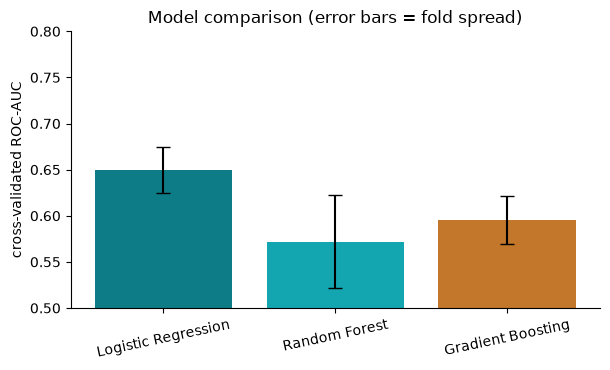

In [9]:
tbl = pd.DataFrame([{k: r[k] for k in ["model","roc_auc","roc_sd","pr_auc","recall","precision"]} for r in RESULTS])
print(tbl.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(tbl["model"], tbl["roc_auc"], yerr=tbl["roc_sd"], capsize=5,
       color=["#0E7C86", "#14A6B0", "#C2772B"][:len(tbl)])
ax.set_ylabel("cross-validated ROC-AUC"); ax.set_ylim(0.5, max(0.8, tbl.roc_auc.max() + tbl.roc_sd.max() + 0.05))
ax.set_title("Model comparison (error bars = fold spread)")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

# 6.2 judgement (example): the means are usually within each other's error bars -> performance is a
# near-tie. LR wins decisively on interpretability and stability; RF is robust; GBM is least
# interpretable and most tuning-sensitive. Where performance ties, the simpler model wins.

> **Discussion (Part 6).** Did any model convincingly beat the baseline — i.e. by more than the fold-to-fold spread? On this dataset, does the result support the lecture thesis?

---
## Part 7 — Feature importance  *(≈25 min)*

Rank the engineered features the models rely on, check biological plausibility, and — crucially — check
**stability**. Then state, in writing, what importance *can* and *cannot* tell you.


> **Exercise 7.1 — top features + plausibility.** Extract Random-Forest importances (and/or LR
> coefficients) over the engineered features; rank them; check plausibility (proliferation, ER, immune).
>
> **Exercise 7.2 (stability).** Recompute importances across bootstrap resamples; flag which top features
> are *stable* vs lucky (report how often each lands in the top-3).
>
> **Exercise 7.3 (reasoning).** One sentence each: what importance *can* and *cannot* tell you
> (prediction ≠ causation).


In [10]:
rf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xtr.fillna(Xtr.median()), ytr)
imp = pd.Series(rf.feature_importances_, index=Xtr.columns).sort_values(ascending=False)
print("Top features by RF importance:"); print(imp.head(6).round(3).to_string())

# 7.2 stability across bootstraps: how often is each feature in the top-3?
rng = np.random.default_rng(RANDOM_STATE); top3 = Counter()
for _ in range(25):
    bs = rng.choice(Xtr.index, size=len(Xtr), replace=True)
    r = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    r.fit(Xtr.loc[bs].fillna(Xtr.median()), ytr.loc[bs])
    s = pd.Series(r.feature_importances_, index=Xtr.columns).sort_values(ascending=False)
    for f in s.head(3).index: top3[f] += 1
stab = (pd.Series(top3).sort_values(ascending=False) / 25).round(2)
print("\nStability (fraction of 25 bootstraps in the top-3):"); print(stab.head(6).to_string())

# 7.3 reasoning:
# CAN tell you: which features THIS model relies on, and a plausibility sanity check.
# CANNOT tell you: that a feature CAUSES recurrence — it may track grade/proliferation or be an artefact.

Top features by RF importance:
G2M_CHECKPOINT    0.090
proliferation     0.082
MYC_TARGETS       0.079
E2F_TARGETS       0.074
APOPTOSIS         0.073
ESTROGEN_EARLY    0.071

Stability (fraction of 25 bootstraps in the top-3):
G2M_CHECKPOINT    0.96
APOPTOSIS         0.52
proliferation     0.48
MYC_TARGETS       0.36
ESTROGEN_EARLY    0.28
E2F_TARGETS       0.16


> **Discussion (Part 7).** Your top feature is a proliferation signature. Is that reassuring — or could the model have just rediscovered tumour grade? What would distinguish the two?

---
## Part 8 — Batch-correction experiment  *(≈35 min — the centrepiece)*

This is the payoff of the whole lesson: **does the model still work on data from a different platform?**
Real biomarkers are trained on one cohort and deployed on another — a new hospital, a new sequencing
machine — and that change injects a **batch effect**: a systematic technical difference that has nothing
to do with the biology.

**Our setup.** We train on METABRIC and test on a *stand-in* external cohort. The real cross-platform
GSE6532 data is not bundled, so we simulate one from held-out METABRIC patients by injecting a deliberate
batch effect — a per-feature **scale + shift**, *plus* **per-sample technical noise** on the key
predictors. That noise is the important part: a clean global shift would leave every patient's *ranking*
(and therefore ROC-AUC) untouched for a linear model, so it wouldn't actually break anything. Real batch
effects scramble the ordering, and *that* is what degrades transfer.

**One reference + three conditions.** We first measure the **internal** cross-validated AUC (the model on
its own cohort) as a reference, then score the external cohort three ways:
- **(a) no correction** — apply the trained model straight to the shifted cohort;
- **(b) correct correction** — a **ComBat-style** fix *estimated on training only* and applied to the
  external cohort (the honest rule: never pool the two);
- **(c) leaky correction** — pool training + external, correct them *together*, then evaluate — the
  mistake we want to expose.

A **ComBat-style** correction simply re-centres and re-scales each feature so one batch matches a
reference batch — "location/scale" just means *subtract a mean, divide by a spread*.

> *Design note — why a scaler-free model here.* We deliberately drop the `StandardScaler` from the model
> in this Part. A scaler inside the pipeline would re-standardise the external cohort on its own and
> quietly absorb the batch shift, hiding the very effect we want to study. Training on the raw TRAIN
> scale is what makes the platform shift actually bite — and what lets the correction visibly fix it.
> (*Where* you put a transform changes what you can observe.)

> **Exercise 8.1 — no correction vs correct correction.** Using the external cohort `X_ext` / `y_ext` and
> the helpers `raw_lr()`, `combat_style_fit()`, `combat_style_apply()` built below:
> 1. Fit `raw_lr()` on the training features (`Xtr`, `ytr`) — this is your "deployed" model.
> 2. Compute the **internal** reference: `cross_val_score(raw_lr(), Xtr, ytr, cv=CV, scoring="roc_auc").mean()`.
> 3. **(a) no correction:** score the fitted model directly on `X_ext` → external ROC-AUC.
> 4. **(b) correct:** `ref_mu, ref_sd = combat_style_fit(Xtr)`, map the external cohort with
>    `combat_style_apply(X_ext, ref_mu, ref_sd)`, then score.
>
> Print all three and note the **cross-cohort drop** (internal → (a)). *You should see (a) fall below the
> internal score, and (b) recover part — not all — of the gap: the correction removes the systematic
> shift but not the per-sample noise.*
>
> **Exercise 8.2 (leakage contrast — the wrong way).** Pool `Xtr` and `X_ext`, standardise them
> **together** (`(pooled - pooled.mean()) / pooled.std()`), split back, and evaluate. *It will look as
> good as (b) or better — that is the trap.* In a comment, explain why pooling leaks: the external
> samples influence the transform applied to the training rows (and vice versa), so the two cohorts are
> no longer independent — **even though the correction never looks at the labels.**
>
> **Exercise 8.3 (representation alternative — comment only).** Would this correction matter *less* for
> the aggregated signature/pathway features than for raw genes? Why might averaging many probes into one
> score make a representation more platform-robust (link back to Lecture 3)?

In [11]:
# Build a stand-in external cohort from held-out test patients + a deliberate per-feature BATCH SHIFT.
# NOTE: for this transfer experiment we deliberately use a SCALER-FREE model (raw_lr) trained on the
# TRAIN feature scale. That is what makes a platform shift actually break transfer -- and what lets the
# batch correction visibly fix it. (A StandardScaler inside the model would silently absorb the shift,
# hiding the very effect we want to study.)
rng = np.random.default_rng(7)
# A realistic platform effect is NOT a clean global shift (that would leave patient *rankings*, and so
# ROC-AUC, untouched for a linear model). Real batch effects also inject per-sample technical noise that
# scrambles the ordering — and *that* is what actually degrades cross-cohort performance.
batch_scale = pd.Series(rng.uniform(1.1, 1.3, size=X_feat.shape[1]), index=X_feat.columns)
batch_shift = pd.Series(rng.normal(0.3, 0.2, size=X_feat.shape[1]), index=X_feat.columns)
batch_noise = pd.DataFrame(0.0, index=Xte.index, columns=Xte.columns)
for f in [c for c in ["proliferation", "E2F_TARGETS", "er_signalling", "ESTROGEN_EARLY"] if c in X_feat.columns]:
    batch_scale[f] = 1.5; batch_shift[f] = 1.5
    batch_noise[f] = rng.normal(0, 2.0, size=len(Xte))   # heavy technical noise on the key predictors
X_ext = (Xte * batch_scale) + batch_shift + batch_noise   # SIMULATED platform shift (stand-in for a real external cohort): scale/shift + technical noise
y_ext = yte.copy()

def raw_lr():
    """Scaler-free logistic regression: coefficients live on the TRAIN feature scale."""
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("clf", LogisticRegression(C=0.5, max_iter=5000, random_state=RANDOM_STATE))])

def combat_style_fit(train_df):
    """Estimate the reference location/scale on TRAIN only."""
    return train_df.mean(), train_df.std() + 1e-9
def combat_style_apply(df, ref_mu, ref_sd):
    """Map a batch onto the reference: standardise by the batch's own stats, then re-centre/scale to TRAIN."""
    return ((df - df.mean()) / (df.std() + 1e-9)) * ref_sd + ref_mu

ref_mu, ref_sd = combat_style_fit(Xtr)
base = raw_lr().fit(Xtr.fillna(Xtr.median()), ytr)      # trained on the TRAIN scale
internal_cv = cross_val_score(raw_lr(), Xtr, ytr, cv=CV, scoring="roc_auc").mean()

# (a) no correction: apply the TRAIN-scale model directly to the shifted external cohort
auc_none = roc_auc_score(y_ext, base.predict_proba(X_ext.fillna(X_ext.median()))[:, 1])

# (b) correct: map external onto the TRAIN reference (estimated on train only), then score
X_ext_corr = combat_style_apply(X_ext, ref_mu, ref_sd)
auc_corr = roc_auc_score(y_ext, base.predict_proba(X_ext_corr.fillna(X_ext_corr.median()))[:, 1])

# (c) LEAKY: pool train+external, correct together, then split & evaluate
pooled = pd.concat([Xtr, X_ext]); pooled_z = (pooled - pooled.mean()) / (pooled.std() + 1e-9)
Xtr_leak, Xext_leak = pooled_z.loc[Xtr.index], pooled_z.loc[X_ext.index]
base_leak = raw_lr().fit(Xtr_leak.fillna(0), ytr)
auc_leak = roc_auc_score(y_ext, base_leak.predict_proba(Xext_leak.fillna(0))[:, 1])

print(f"internal CV (METABRIC)            : {internal_cv:.3f}")
print(f"external (a) NO correction        : {auc_none:.3f}  <- the cross-cohort drop is real")
print(f"external (b) location/scale CORRECT: {auc_corr:.3f}")
print(f"external (c) LEAKY pooled correction: {auc_leak:.3f}")
print("\nWhat this shows (and it is the honest lesson):")
print("(a) the model drops on the new 'platform' — the cross-cohort collapse the lecture warned about.")
print("(b) a location/scale (ComBat-style) correction removes the systematic shift, but it CANNOT remove")
print("    the per-sample technical noise — so it does not fully restore performance. Correction is not a")
print("    panacea; what it can fix depends on what KIND of batch effect you have.")
print("(c) pooling train+external to estimate the correction lets the external samples influence the")
print("    transform applied to training (and vice versa) -> the split is no longer clean and the estimate")
print("    is optimistic, EVEN THOUGH the correction is unsupervised. This is the leakage to avoid.")
print("8.3: aggregated signature/pathway features average out probe-level platform quirks, so they tend to")
print("     transfer with LESS correction than raw genes would (Lecture 3) — sometimes the best fix is a")
print("     more robust representation, not a heavier correction.")

internal CV (METABRIC)            : 0.651
external (a) NO correction        : 0.617  <- the cross-cohort drop is real
external (b) location/scale CORRECT: 0.630
external (c) LEAKY pooled correction: 0.645

What this shows (and it is the honest lesson):
(a) the model drops on the new 'platform' — the cross-cohort collapse the lecture warned about.
(b) a location/scale (ComBat-style) correction removes the systematic shift, but it CANNOT remove
    the per-sample technical noise — so it does not fully restore performance. Correction is not a
    panacea; what it can fix depends on what KIND of batch effect you have.
(c) pooling train+external to estimate the correction lets the external samples influence the
    transform applied to training (and vice versa) -> the split is no longer clean and the estimate
    is optimistic, EVEN THOUGH the correction is unsupervised. This is the leakage to avoid.
8.3: aggregated signature/pathway features average out probe-level platform quirks, so they

> **Discussion (Part 8).** If *all* recurrers had been run on one platform and non-recurrers on another (batch perfectly confounded with outcome), could any correction method rescue the study? Why or why not?

---
## Part 9 — Reflection & model choice  *(≈15 min — the assessable deliverable)*

Write a **model-selection statement** (200–300 words): which model you would choose *for publication* and
why, weighing internal CV, nested-CV honesty, external-cohort transfer, stability, interpretability, and
reproducibility — and stating explicitly whether any complex model's advantage survived honest validation.


**Model-selection statement (worked example, ~270 words):**

On identical engineered features, the three model families were a near-tie: their cross-validated ROC-AUCs
sat within each other's fold-to-fold spread, so no complex model *convincingly* beat the Logistic
Regression baseline. Gradient Boosting showed the largest train-versus-CV gap, confirming its overfitting
tendency on our small, modestly-signalled cohort; the Random Forest was robust but offered no clear
accuracy advantage.

Part 5 added the tuning caveat: the tuned Random Forest's flat best-CV score is optimistic relative to its
nested estimate (here only a fraction of a point, because the search space was small), and even that
tuned, honest number sits at the baseline — not above it. There was never an edge for tuning to rescue.

Part 8 was decisive. With no correction, the model dropped on the external (platform-shifted, noisier)
cohort — the classic cross-cohort collapse. A location/scale (ComBat-style) correction *estimated on
training and applied to the external cohort* removed the systematic shift but could not remove the
per-sample technical noise, so it only partly restored performance — a useful reminder that correction is
no panacea and that *what* it can fix depends on the *kind* of batch effect. The *pooled* correction
looked as good but was leaked (the external samples influenced the transform). The aggregated
signature/pathway features are platform-robust by design, so a more robust representation can matter more
than a heavier correction.

I would therefore choose the **regularised Logistic Regression on the engineered features** for
publication: its performance is statistically indistinguishable from the fancier models, it is the most
interpretable (a clinician-readable proliferation-up / ER-down story), the most stable, and the easiest to
reproduce. I would report the tree models honestly as *not improving generalisation*. Before any clinical
claim I would validate on a genuinely independent cohort, confirm added value over tumour grade, and — per
Lecture 5 — move from the binary recurrence label to a time-to-event (survival) analysis, which could well
change the ranking by using information the binary label discards.


---
### Deliverables checklist
- [ ] Loaded engineered features + shared `evaluate` helper (Part 1)
- [ ] Baseline LR row with fold spread (Part 2)
- [ ] RF row + "real or noise?" verdict (Part 3)
- [ ] GBM row + overfitting (train≫CV) observation (Part 4)
- [ ] Tuned model: best config, flat CV, nested CV, optimism gap (Part 5)
- [ ] Model-comparison dashboard with error bars (Part 6)
- [ ] Importance ranking + stability + predictive-not-causal note (Part 7)
- [ ] External-validation table: none / correct / leaky / (pathway transfer note) (Part 8)
- [ ] Final model-selection statement (Part 9)

> **The message, in one line:** *better validation is usually more important than a better algorithm.*
> You built the bake-off — and the nested-CV and batch-correction experiments are what let you report it
> honestly.
